### Прогноз стоимости недвижимости в Турции

### Импорт необходимых библиотек

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1 Знакомство с данными

Загрузим датасет и посмотрим на его структуру. Определим количество строк и столбцов, а также типы данных.

In [52]:
df = pd.read_csv('real_estate_data.csv', encoding='utf-8', low_memory=False)

In [53]:
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размер датасета: 403487 строк, 17 столбцов


In [54]:
print("\nПервые 5 строк:")
display(df.head())


Первые 5 строк:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [55]:
print("\nКрайние 5 строк:")
display(df.tail())


Крайние 5 строк:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [56]:
# Просмотр случайной строки для понимания структуры
print("\nСлучайная строка:")
display(df.sample(1))


Случайная строка:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
307211,307212,Konut,Daire,11/19/18,2/2/19,1,75,0,8,5,1+1,60.0,Çanakkale/Merkez/İsmetpaşa,NaN,Merkezi Sistem (Isı Payı Ölçer),135000.0,TRY


In [57]:
# Общая информация о типах данных и количестве ненулевых значений
print("\nИнформация о столбцах:")
df.info()


Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 n

#### Описание признаков:
*   type - Тип недвижимости (например, Konut - жилое).
*   sub_type - Подтип (квартира, резиденс и т.д.).
*   start_date / end_date - Даты размещения и снятия объявления.
*   listing_type - Тип листинга(продажа, аренда, посуточная аренда).
*   tom - Время нахождения на рынке (days on market).
*   building_age - Возраст здания.
*   total_floor_count / floor_no - Этажность дома и номер этажа.
*   room_count - Количество комнат.
*   size - Площадь в квадратных метрах.
*   address - Полный адрес (Город/Район/Микрорайон).
*   heating_type -: Тип отопления.
*   price - Целевая переменная — цена объекта.
*   price_currency - Валюта

## 1.2 Описательная статистика
Рассчитаем базовые статистики для числовых признаков и оценим распределение категорий.

In [58]:
# Статистика по числовым признакам
print("Числовые признаки")
display(df.describe())

# Уникальные значения в категориальных столбцах
print("Категориальные признаки (уникальные значения)")
display(df.select_dtypes(include=['object']).nunique().sort_values(ascending=False))

Числовые признаки


,id,listing_type,tom,size,furnished,price
count,403487.00000,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,201744.00000,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,116476.80837,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.00000,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,100872.50000,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,201744.00000,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,302615.50000,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,403487.00000,3.000000,180.000000,948235.000000,NaN,2.000000e+09


Категориальные признаки (уникальные значения)


address              7842
end_date              181
start_date            181
room_count             37
floor_no               35
heating_type           16
building_age           14
total_floor_count      12
sub_type               12
price_currency          4
type                    1
dtype: int64

## 1.4 Анализ пропусков и аномалий
Проверим данные на наличие пропущенных значений, дубликатов и логических ошибок.

Заменяем Size на медиану

In [59]:
df['size'] = df['size'].fillna(df['size'].median())
print(df['size'].describe())

count    403487.000000
mean        218.068349
std        7532.818307
min           1.000000
25%         100.000000
50%         110.000000
75%         124.000000
max      948235.000000
Name: size, dtype: float64


И убираем выбросы

In [60]:
df = df[(df['size'] >= 10) & (df['size'] <= 2000)]
print("Осталось строк:", len(df))
print(df['size'].describe())

Осталось строк: 402744
count    402744.000000
mean        119.690940
std          66.522646
min          10.000000
25%         100.000000
50%         110.000000
75%         123.000000
max        2000.000000
Name: size, dtype: float64


Удаляем столбец furnished, так как он полностью пустой и на работу не повлияет

In [61]:
df = df.drop(columns=['furnished'])

Обрабатывать данный столбец не будем, пропусков в нем нет и одно единственное значение для всех

In [62]:
print(df['type'].unique()[:20])

['Konut']


Для удобства переводим значение типа помещения в число

In [63]:
print(df['sub_type'].unique()[:20])

['Rezidans' 'Daire' 'Villa' 'Müstakil Ev' 'Yazlık' 'Komple Bina'
 'Prefabrik Ev' 'Köşk / Konak / Yalı' 'Çiftlik Evi' 'Yalı Dairesi' 'Loft'
 'Kooperatif']


In [64]:
print(df['sub_type'].value_counts(dropna=False))

sub_type
Daire                  354167
Villa                   21212
Müstakil Ev              9477
Rezidans                 7698
Yazlık                   5922
Komple Bina              2548
Prefabrik Ev              676
Çiftlik Evi               462
Köşk / Konak / Yalı       296
Yalı Dairesi              187
Kooperatif                 65
Loft                       34
Name: count, dtype: int64


In [65]:
sub_type_map = {
    'Daire': 0,
    'Villa': 1,
    'Müstakil Ev': 2,
    'Rezidans': 3,
    'Yazlık': 4,
    'Komple Bina': 5,
    'Prefabrik Ev': 6,
    'Çiftlik Evi': 7,
    'Köşk / Konak / Yalı': 8,
    'Yalı Dairesi': 9,
    'Kooperatif': 10,
    'Loft': 11,
}

df['sub_type'] = df['sub_type'].map(sub_type_map)
print(df['sub_type'].dtype)        # int64
print(df['sub_type'].value_counts().sort_index())

int64
sub_type
0     354167
1      21212
2       9477
3       7698
4       5922
5       2548
6        676
7        462
8        296
9        187
10        65
11        34
Name: count, dtype: int64


Так же переводим значение комнат в единое число

In [66]:
print(df['room_count'].unique()[:20])

['2+1' '1+0' '6+1' '1+1' '3+1' '4+1' '2+2' '9+2' '5+2' '6+2' '4+3' '9+5'
 '5+1' '3+2' '+' '4+2' '7+2' '8+2' '8+3' '8+1']


In [67]:
print("Пропусков:", df['room_count'].isna().sum())
print(df['room_count'].value_counts().sort_index())

Пропусков: 0
room_count
+         2836
0+0          1
1+0       2597
1+1      39085
10+0       296
10+1        33
10+2        25
10+3         9
10+4         1
10+5         2
11+3         1
15+5         1
2+1     138505
2+2        834
3+1     157170
3+2       2667
4+1      37412
4+2       4522
4+3        127
5+1       8200
5+2       2907
5+3        136
6+1       1988
6+2       1502
6+3        161
7+1        520
7+2        412
7+3         79
8+1        212
8+2        186
8+3         45
8+4         33
9+1         71
9+2         58
9+3         63
9+4         24
9+5         23
Name: count, dtype: int64


In [68]:
import numpy as np
import re

def parse_rooms(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().replace(' ', '')
    # "2+1" -> 3
    m = re.match(r'^(\d+)\+(\d+)$', x)
    if m:
        return int(m.group(1)) + int(m.group(2))
    # просто число "3" -> 3 (на всякий случай)
    m = re.match(r'^(\d+)$', x)
    if m:
        return int(m.group(1))
    # всё остальное ('+', пустое) -> NaN
    return np.nan

df['room_count'] = df['room_count'].apply(parse_rooms)

In [69]:
# медианой (будет 3 — самая частая)
df['room_count'] = df['room_count'].fillna(df['room_count'].median()).astype(int)

print(df['room_count'].describe())
print(df['room_count'].dtype)      # int64
print("Пропусков:", df['room_count'].isna().sum())   # 0

count    402744.000000
mean          3.689562
std           1.128139
min           0.000000
25%           3.000000
50%           4.000000
75%           4.000000
max          20.000000
Name: room_count, dtype: float64
int64
Пропусков: 0


Убираем слишком маленькие и слишком большие

In [70]:
# 1. сколько строк с room_count > 10
print("room_count > 10:", (df['room_count'] > 10).sum())
print(df['room_count'].value_counts().sort_index())

room_count > 10: 318
room_count
0          1
1       2597
2      39085
3     138505
4     160840
5      40079
6      12722
7       5022
8       2158
9        785
10       632
11       136
12       121
13        33
14        25
15         2
20         1
Name: count, dtype: int64


In [71]:
df = df[(df['room_count'] >= 1) & (df['room_count'] <= 10)]
print("Осталось:", len(df))

Осталось: 402425


Обработка типа обогрева

In [72]:
print(df['heating_type'].value_counts(dropna=False))

heating_type
Kombi (Doğalgaz)                   203763
Klima                               68024
Merkezi Sistem (Isı Payı Ölçer)     30568
NaN                                 27859
Merkezi Sistem                      22808
Kalorifer (Doğalgaz)                10885
Soba (Kömür)                         8365
Yerden Isıtma                        6930
Yok                                  6072
Kat Kaloriferi                       5599
Kombi (Elektrikli)                   3442
Soba (Doğalgaz)                      2586
Güneş Enerjisi                       1736
Kalorifer (Kömür)                    1493
Jeotermal                            1415
Fancoil                               476
Kalorifer (Akaryakıt)                 404
Name: count, dtype: int64


In [73]:
df['heating_type'] = df['heating_type'].fillna('unknown')

counts = df['heating_type'].value_counts(normalize=True)
rare = counts[counts < 0.005].index.tolist()# меняем самые редкие в группу other
print("Объединяем в Other:", rare)

df['heating_type'] = df['heating_type'].replace(rare, 'Other')
print(df['heating_type'].value_counts())

Объединяем в Other: ['Güneş Enerjisi', 'Kalorifer (Kömür)', 'Jeotermal', 'Fancoil', 'Kalorifer (Akaryakıt)']
heating_type
Kombi (Doğalgaz)                   203763
Klima                               68024
Merkezi Sistem (Isı Payı Ölçer)     30568
unknown                             27859
Merkezi Sistem                      22808
Kalorifer (Doğalgaz)                10885
Soba (Kömür)                         8365
Yerden Isıtma                        6930
Yok                                  6072
Kat Kaloriferi                       5599
Other                                5524
Kombi (Elektrikli)                   3442
Soba (Doğalgaz)                      2586
Name: count, dtype: int64


In [74]:
heating_map = {
    'Yok': 0,                               # нет отопления — худшее
    'Soba (Kömür)': 1,                      # угольная печь
    'Soba (Doğalgaz)': 2,                   # газовая печь
    'Kalorifer (Kömür)': 3,                 # угольный котёл
    'Kalorifer (Akaryakıt)': 4,             # мазутный котёл
    'Klima': 5,                             # кондиционер
    'Kat Kaloriferi': 6,                    # этажный котёл
    'Kalorifer (Doğalgaz)': 7,              # газовый котёл (общий)
    'Kombi (Elektrikli)': 8,                # электрический котёл
    'Kombi (Doğalgaz)': 9,                  # газовый котёл (индивидуальный) — самый частый
    'Merkezi Sistem': 10,                   # центральное
    'Merkezi Sistem (Isı Payı Ölçer)': 11,  # центральное со счётчиком
    'Fancoil': 12,                          # фанкойл
    'Yerden Isıtma': 13,                    # тёплый пол
    'Jeotermal': 14,                        # геотермальное
    'Güneş Enerjisi': 15,                   # солнечная энергия
}

df['heating_type'] = df['heating_type'].map(heating_map)

# пропуски — медианой (самое частое — Kombi Doğalgaz = 9)
median_val = df['heating_type'].median()
print("Медиана:", median_val)   # ожидаем ~9
df['heating_type'] = df['heating_type'].fillna(median_val).astype(int)

print(df['heating_type'].dtype)      # int64
print(df['heating_type'].describe())
print(df['heating_type'].value_counts().sort_index())

Медиана: 9.0
int64
count    402425.000000
mean          8.149876
std           2.393169
min           0.000000
25%           7.000000
50%           9.000000
75%           9.000000
max          13.000000
Name: heating_type, dtype: float64
heating_type
0       6072
1       8365
2       2586
5      68024
6       5599
7      10885
8       3442
9     237146
10     22808
11     30568
13      6930
Name: count, dtype: int64


Переводим номер этажа в числовое значение

In [75]:
print(df['floor_no'].unique()[:20])

['2' '20 ve üzeri' 'Yüksek Giriş' '10' '14' nan 'Kot 2' 'Asma Kat'
 'Bahçe katı' '11' '3' '13' '7' '16' 'Müstakil' '19' '4' '5' '8' '15']


Значения:

числа: '2', '10', '14', '3', '13', '7', '16', '19', '4', '5', '11'

'20 ve üzeri' → 25

'Yüksek Giriş' — «высокий первый этаж» (полуэтаж над землёй, условно 0.5 или 1)

'Kot 2' — подвал 2-го уровня → -2

'Kot 1' — подвал 1-го уровня → -1 (если встретится)

'Asma Kat' — антресоль → 0.5

'Bahçe katı' — цокольный/садовый этаж → -1

'Zemin Kat' — первый этаж (ground floor) → 0

'Müstakil' — отдельно стоящий дом → 0

'En Üst Kat' — последний этаж → сложно, зависит от total_floor_count; можно поставить 0.5 или total_floor_count

nan — пропуски

In [76]:
import numpy as np
import re

floor_map = {
    'yüksek giriş': 0.5,
    'asma kat': 0.5,
    'zemin kat': 0,
    'bahçe katı': -1,
    'kot 1': -1,
    'kot 2': -2,
    'kot 3': -3,
    'müstakil': 0,
}

def parse_floor_no(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    x = str(x).strip().lower()

    # "en üst kat" — вернём специальный маркер для последнего этажа
    if 'en üst' in x:
        return -999.0

    if x in floor_map:
        return floor_map[x]

    # "20 ve üzeri" -> 25
    if 'üzeri' in x:
        m = re.search(r'(\d+)', x)
        return float(m.group(1)) + 5 if m else np.nan

    # интервал "10-20 arası" -> 15
    m = re.match(r'(\d+)\s*-\s*(\d+)', x)
    if m:
        return (int(m.group(1)) + int(m.group(2))) / 2

    # просто число
    m = re.match(r'^(\d+(?:\.\d+)?)$', x)
    if m:
        return float(m.group(1))

    return np.nan

# 1. парсим
df['floor_no'] = df['floor_no'].apply(parse_floor_no).astype(float)

# 2. убедимся, что total_floor_count — числовой
df['total_floor_count'] = pd.to_numeric(df['total_floor_count'], errors='coerce').astype(float)

# 3. заменяем маркер -999 на total_floor_count
mask = df['floor_no'] == -999.0
df.loc[mask, 'floor_no'] = df.loc[mask, 'total_floor_count']

# 4. теперь медиана работает
df['floor_no'] = df['floor_no'].fillna(df['floor_no'].median())

print(df['floor_no'].describe())

count    402425.000000
mean          2.687546
std           3.157891
min          -3.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          25.000000
Name: floor_no, dtype: float64


-3 - подвалы Kot 3

Переводим значение всего этажей в единое число

In [77]:
print(df['total_floor_count'].unique()[:20])

[nan  1.  4.  2.  3.  8.  6.  5. 10.  9.  7.]


In [78]:
# "20 ve üzeri" -> 25
# "10-20 arası" -> 15
# "8" -> 8.0
import numpy as np
import re

def parse_floor_count(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float, np.number)): return float(x)
    x = str(x).strip().lower()

    # "20 ve üzeri" -> 25
    if 'üzeri' in x:
        m = re.search(r'(\d+)', x)
        return float(m.group(1)) + 5 if m else np.nan

    # "10-20 arası" -> 15
    m = re.match(r'(\d+)\s*-\s*(\d+)', x)
    if m:
        return (int(m.group(1)) + int(m.group(2))) / 2

    # "8" -> 8.0
    m = re.match(r'^(\d+(?:\.\d+)?)$', x)
    if m:
        return float(m.group(1))

    return np.nan

df['total_floor_count'] = df['total_floor_count'].apply(parse_floor_count)
df['total_floor_count'] = df['total_floor_count'].fillna(df['total_floor_count'].median())
df['total_floor_count'] = df['total_floor_count'].round().astype(int)

print(df['total_floor_count'].describe())
print(df['total_floor_count'].value_counts().sort_index())

count    402425.000000
mean          4.425232
std           1.789228
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max          10.000000
Name: total_floor_count, dtype: float64
total_floor_count
1       4865
2      27548
3      77693
4     153963
5      70039
6      23310
7      12267
8      11191
9       9010
10     12539
Name: count, dtype: int64


In [79]:
# 1. Удаление строки с отрицательной ценой или нулевой площадью
df = df[(df['price'] > 0) & (df['size'] > 0)]
upper_limit = df['price'].quantile(0.99)
lower_limit = df['price'].quantile(0.01) 
df = df[(df['price'] <= upper_limit) & (df['price'] >= lower_limit)]

Переводим цену в одну валюту, самую частую для удобства try-турецкая лира

In [80]:
print(df['price_currency'].unique()[:20])

['TRY' 'GBP' 'EUR' 'USD']


In [81]:
print(df['price_currency'].value_counts())

price_currency
TRY    391906
EUR       850
GBP       555
USD       441
Name: count, dtype: int64


In [82]:
import numpy as np

#  Курсы на 12.09.2026 
rates_to_try = {
    'TRY': 1.0,
    'USD': 48.52,
    'EUR': 56.28,
    'GBP': 65.63,
}

# Заполнить пропуски валюты самой частой (TRY) 
most_common = df['price_currency'].mode()[0]
print("Заполняем пропуски валютой:", most_common)   
df['price_currency'] = df['price_currency'].fillna(most_common)

# Перевести цену в TRY 
df['price_try'] = df['price'] * df['price_currency'].map(rates_to_try)

# Проверка
print(df.groupby('price_currency')['price'].agg(['count', 'mean', 'median']))
print("\nprice_try:")
print(df['price_try'].describe())

df = df.drop(columns=['price', 'price_currency'])   # удаляем старую цену и валюту
df = df.rename(columns={'price_try': 'price'})      # переименовываем price_try → price

Заполняем пропуски валютой: TRY
                 count           mean    median
price_currency                                 
EUR                850  150432.287059   79000.0
GBP                555  138711.264865   70000.0
TRY             391906  260923.353922  199000.0
USD                441  581958.537415  350000.0

price_try:
count    3.937520e+05
mean     3.224331e+05
std      1.787798e+06
min      5.000000e+02
25%      2.700000e+03
50%      2.000000e+05
75%      3.400000e+05
max      1.741449e+08
Name: price_try, dtype: float64


Приводим столбец building_age к числовому значению для дальнейшего удобства в анализе

In [83]:
import numpy as np
import pandas as pd
import re
# Содержались слова на турецком языке, их уберераем и берем число, в случае диапазона берем среднее, просто числа оставляем как есть
def parse_building_age(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()

    if 'üzeri' in x:
        m = re.search(r'(\d+)', x)
        return float(m.group(1)) + 5 if m else np.nan

    m = re.match(r'(\d+)\s*-\s*(\d+)', x)
    if m:
        return (int(m.group(1)) + int(m.group(2))) / 2

    m = re.match(r'^(\d+)$', x)
    if m:
        return float(m.group(1))

    return np.nan

# 1. парсим в float
df['building_age'] = df['building_age'].apply(parse_building_age)

# 2. смотрим, что получилось
print("Пропусков после парсинга:", df['building_age'].isna().sum())
print("Медиана:", df['building_age'].median())

# 3. заполняем медианой, а если медиана NaN — нулём
median_val = df['building_age'].median()
if pd.isna(median_val):
    median_val = 0
df['building_age'] = df['building_age'].fillna(median_val)

# 4. только теперь — int
df['building_age'] = df['building_age'].round().astype(int)

print(df['building_age'].dtype)
print(df['building_age'].describe())

Пропусков после парсинга: 26017
Медиана: 3.0
int64
count    393752.000000
mean          6.600078
std           8.442624
min           0.000000
25%           0.000000
50%           3.000000
75%           8.000000
max          45.000000
Name: building_age, dtype: float64


In [84]:
# Таблица пропусков
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент': missing_percent})
missing_df = missing_df[missing_df['Пропуски'] > 0].sort_values(by='Пропуски', ascending=False)

print("Таблица пропусков")
display(missing_df)

# Проверка на дубликаты
print(f"\nКоличество полных дубликатов строк: {df.duplicated().sum()}")

# Логическая проверка (аномалии)
print(f"Строк с отрицательной ценой: {(df['price'] < 0).sum()}")
print(f"Минимальная цена: {df['price'].min()}")
print(f"Максимальная цена: {df['price'].max()}")
# Логическая проверка (аномалии)
print(f"Строк с отрицательным размером: {(df['size'] < 0).sum()}")
print(f"Минимальный размер: {df['size'].min()}")
print(f"Максимальный размер: {df['size'].max()}")

Таблица пропусков


,Пропуски,Процент
end_date,133086,33.799447



Количество полных дубликатов строк: 0
Строк с отрицательной ценой: 0
Минимальная цена: 500.0
Максимальная цена: 174144873.42
Строк с отрицательным размером: 0
Минимальный размер: 10.0
Максимальный размер: 2000.0


In [85]:
print(f"Размер датасета после очистки выбросов: {df.shape[0]} строк")

Размер датасета после очистки выбросов: 393752 строк


In [86]:
df.describe()

,id,sub_type,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,heating_type,price
count,393752.000000,393752.000000,393752.000000,393752.000000,393752.000000,393752.000000,393752.000000,393752.000000,393752.000000,393752.000000,3.937520e+05
mean,201627.659707,0.262599,1.285484,56.924889,6.600078,4.431264,2.685417,3.672807,118.257350,8.155367,3.224331e+05
std,115865.518526,0.896205,0.452005,44.299344,8.442624,1.788808,3.144042,1.067227,59.093759,2.383788,1.787798e+06
min,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,-3.000000,1.000000,10.000000,0.000000,5.000000e+02
25%,101728.750000,0.000000,1.000000,29.000000,0.000000,3.000000,1.000000,3.000000,100.000000,7.000000,2.700000e+03
50%,201871.500000,0.000000,1.000000,40.000000,3.000000,4.000000,2.000000,4.000000,110.000000,9.000000,2.000000e+05
75%,301140.250000,0.000000,2.000000,90.000000,8.000000,5.000000,4.000000,4.000000,121.000000,9.000000,3.400000e+05
max,403487.000000,11.000000,3.000000,180.000000,45.000000,10.000000,25.000000,10.000000,2000.000000,13.000000,1.741449e+08


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393752 entries, 0 to 403486
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 393752 non-null  int64  
 1   type               393752 non-null  object 
 2   sub_type           393752 non-null  int64  
 3   start_date         393752 non-null  object 
 4   end_date           260666 non-null  object 
 5   listing_type       393752 non-null  int64  
 6   tom                393752 non-null  int64  
 7   building_age       393752 non-null  int64  
 8   total_floor_count  393752 non-null  int64  
 9   floor_no           393752 non-null  float64
 10  room_count         393752 non-null  int64  
 11  size               393752 non-null  float64
 12  address            393752 non-null  object 
 13  heating_type       393752 non-null  int64  
 14  price              393752 non-null  float64
dtypes: float64(3), int64(8), object(4)
memory usage: 48.1+ M

Как итог: полностью чистый датасет, end_date - остается, так как это значит, что обьявление еще активно

## 1.3 Визуальный анализ
Построим 5 различных типов графиков для выявления закономерностей и аномалий.

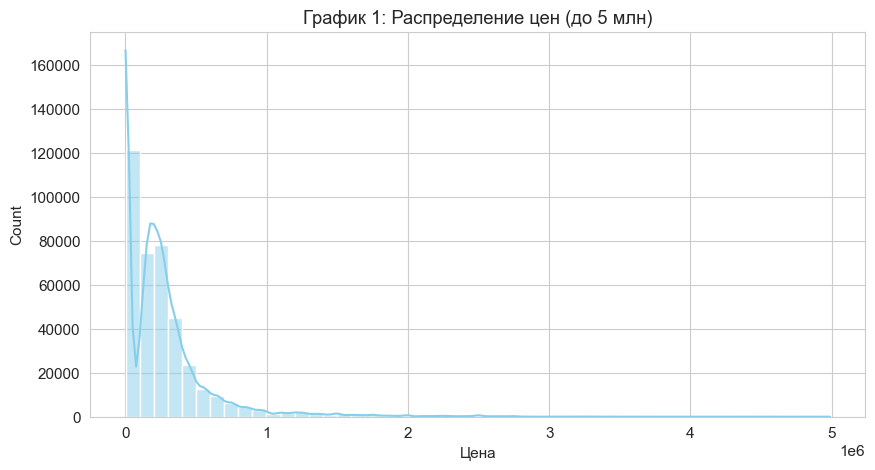

In [204]:
plt.figure(figsize=(10, 5))
# Ограничим выборку до 5 млн для наглядности основного распределения
df_clean_hist = df[df['price'] < 5000000]
sns.histplot(df_clean_hist['price'], bins=50, kde=True, color='skyblue')
plt.title('График 1: Распределение цен (до 5 млн)')
plt.xlabel('Цена')
plt.show()

Распределение типично для цен на недвижимость: сильно скошено вправо, с длинным хвостом дорогих объектов и острым пиком дешёвых.

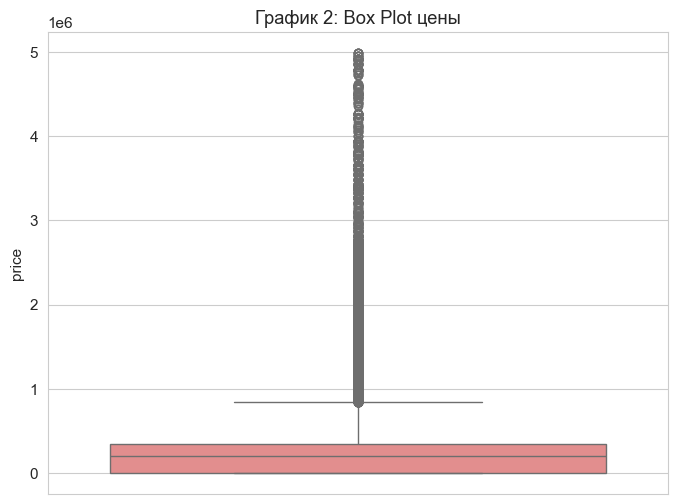

In [205]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_clean_hist['price'], color='lightcoral')
plt.title('График 2: Box Plot цены')
plt.show()

График показывает распределение цены:

Медиана ~200 000 TRY — половина объявлений дешевле, половина дороже.

Основная масса (IQR) — от ~100 000 до ~400 000 TRY.

Нижний ус — почти 0.

Верхний ус — ~900 000 TRY.

Всё выше ~900 000 TRY — выбросы. Их очень много — плотный столб точек до 5 000 000 TRY.

Вывод по цене: рынок сильно смещён в дешёвую сторону, дорогих объектов мало, но они есть, и их так много, что они образуют длинный хвост до 5 млн. 

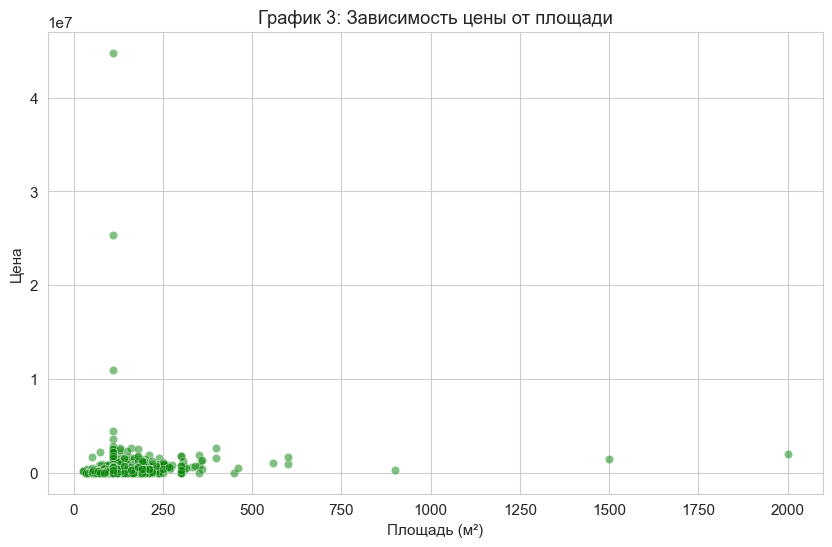

In [206]:
plt.figure(figsize=(10, 6))
sample_scatter = df.dropna(subset=['size', 'price']).sample(2000) 
sns.scatterplot(data=sample_scatter, x='size', y='price', alpha=0.5, color='green')
plt.title('График 3: Зависимость цены от площади')
plt.xlabel('Площадь (м²)')
plt.ylabel('Цена')
plt.show()

На графике видно:

Основная масса точек — плотная зелёная «полоса» внизу слева, в районе площади 50–300 м² и цены около 0–500 000 TRY.

Один выброс вверху — точка при площади ~110 м² и цене ~5 000 000 TRY (5e6, ось Y в 1e7).

Второй выброс — ~250 м², цена ~2 500 000 TRY.


Точка справа — ~600 м², цена ~2 000 000 TRY.

Отдельные точки — 400, 500, 680, 800 м² — цены низкие, около 0–200 000 TRY.

Вывод: чёткой линейной связи между ценой и площадью не видно. Основная масса — внизу, а несколько дорогих объектов при небольшой площади дают выбросы вверх. 

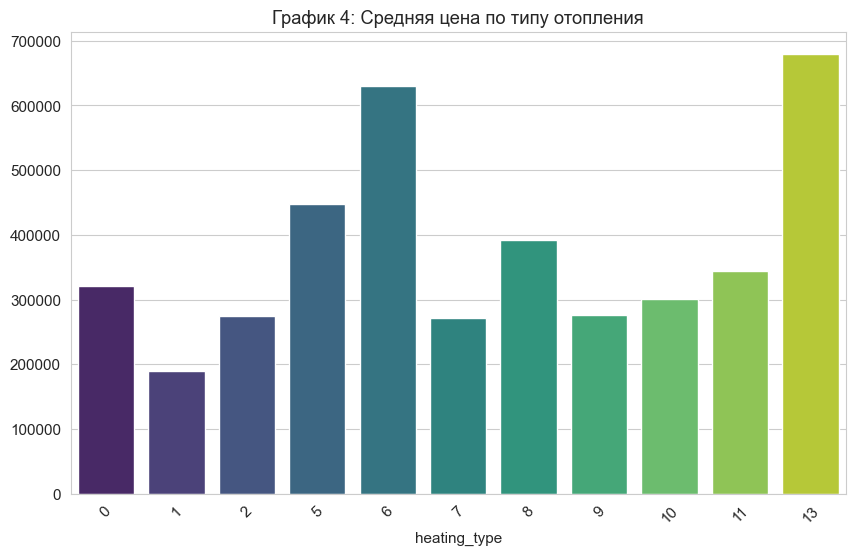

In [207]:
# График 4: Bar Plot (Средняя цена по типу отопления)
plt.figure(figsize=(10, 6))
heating_price = df.groupby('heating_type')['price'].mean().sort_values(ascending=False)
sns.barplot(x=heating_price.index, y=heating_price.values, palette='viridis')
plt.title('График 4: Средняя цена по типу отопления')
plt.xticks(rotation=45)
plt.show()


На графике видно:

Столбцы — средняя цена для каждого типа отопления

Самый низкий — тип 1 (~190 000 TRY), это Soba (Kömür) — угольная печь.

Самый высокий — тип 13 (~680 000 TRY), это Yerden Isıtma — тёплый пол.

Второй по высоте — тип 6 (~620 000 TRY), это Kat Kaloriferi.

Тип 5 — ~450 000 TRY.

Тип 8 — ~390 000 TRY.

Тип 11 — ~350 000 TRY.

Тип 0 — ~320 000 TRY.

Типы 10, 9, 7, 2 — в районе 270–300 тыс. TRY.

Вывод: тип отопления влияет на цену. Разница между самым дешёвым (тип 1) и самым дорогим (тип 13) — примерно в 3.5 раза (190k vs 680k). Это значит, что heating_type — полезный признак для модели

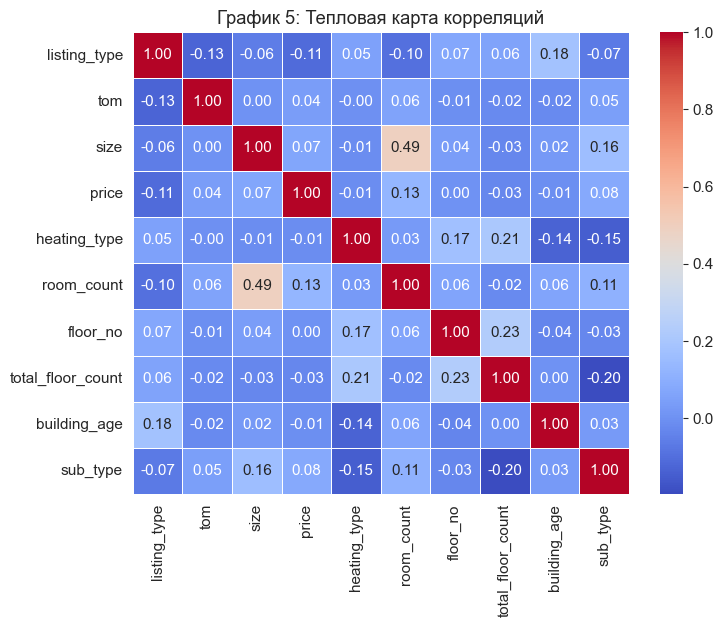

In [208]:
# График 5: Heatmap (Корреляция числовых признаков)
numeric_cols = ['listing_type', 'tom', 'size', 'price', 'heating_type', 'room_count', 'floor_no', 'total_floor_count', 'building_age', 'sub_type']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('График 5: Тепловая карта корреляций')
plt.show()

На графике видно:
Связь с price — почти все корреляции очень слабые (0.07, 0.13, -0.11, -0.01). Самая заметная — room_count → price = 0.13.
size ↔ room_count = 0.49 — умеренная связь (больше комнат → больше площадь).
heating_type ↔ total_floor_count = -0.20.
building_age ↔ listing_type = 0.18.
sub_type ↔ total_floor_count = -0.20.
Вывод: ни один признак сильно не коррелирует с ценой (максимум 0.13). Это значит, что линейная зависимость слабая — нужны либо нелинейные модели (деревья), либо новые признаки.

## 1.5 Промежуточные выводы и гипотезы

На основе проведенного анализа можно сформулировать следующие гипотезы:

1.  **Количество комнат коррелирует с ценой** 
2.  **Данные требуют серьезной очистки:** Обнаружены выбросы.
3.  **Тип отопления влияет на стоимость:** Объекты с центральным или газовым отоплением в среднем стоят дороже.
4.  **Тип листинга(продажа, аренда)** влияет на цену

#### Этап 2.

In [88]:
#  Разбиваем адрес на Город, Район и Микрорайон
df[['city', 'district', 'neighborhood']] = df['address'].str.split('/', expand=True)


#  Создаем новый признак: Площадь на одну комнату
df['size_per_room'] = df['size'] / df['room_count'].replace(0, 1)

# 5. Извлекаем месяц из даты начала объявления (сезонность может влиять на цену)
df['start_month'] = pd.to_datetime(df['start_date'], format='%m/%d/%y').dt.month
print("Новые признаки успешно созданы!")
df[['city',  'size_per_room', 'start_month']].head()

Новые признаки успешно созданы!


,city,size_per_room,start_month
0,İstanbul,30.000000,12
1,İstanbul,43.000000,2
2,Tekirdağ,36.666667,10
4,İstanbul,30.000000,12
5,İstanbul,22.500000,11


Делаем город числовым признаком

In [42]:
from sklearn.preprocessing import LabelEncoder

city_map = {city: i for i, city in enumerate(df['city'].unique())}
df['city'] = df['city'].map(city_map).astype(np.int32)

# Удаляем лишние текстовые столбцы, которые больше не нужны
df_final = df.drop(['address', 'type', 'start_date', 'end_date' ], axis=1)

Убираем выбросы, которые были видны на диаграммах

In [43]:
import numpy as np

# Выбросы в price (по box plot) 
q_low  = df_final['price'].quantile(0.01)
q_high = df_final['price'].quantile(0.99)
print(f"price: обрезаем до [{q_low:,.0f}, {q_high:,.0f}] TRY")

df_final = df_final[(df_final['price'] >= q_low) & (df_final['price'] <= q_high)]

# Выбросы в size (если ещё остались)
df_final = df_final[(df['size'] >= 10) & (df_final['size'] <= 2000)]

# Выбросы по связи price/size (scatter plot) 
df_final['price_per_m2'] = df_final['price'] / df_final['size']
q_low_m2  = df_final['price_per_m2'].quantile(0.01)
q_high_m2 = df_final['price_per_m2'].quantile(0.99)
print(f"price_per_m2: обрезаем до [{q_low_m2:,.0f}, {q_high_m2:,.0f}] TRY/м²")

df_final = df_final[(df_final['price_per_m2'] >= q_low_m2) & (df_final['price_per_m2'] <= q_high_m2)]
df_final = df_final.drop(columns=['price_per_m2'])

# Проверка 
print("\nОсталось строк:", len(df))
print("\nprice:")
print(df['price'].describe())
print("\nsize:")
print(df['size'].describe())

price: обрезаем до [600, 1,980,000] TRY


C:\Users\User\AppData\Local\Temp\ipykernel_20564\3755423324.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_final = df_final[(df['size'] >= 10) & (df_final['size'] <= 2000)]


price_per_m2: обрезаем до [6, 11,364] TRY/м²

Осталось строк: 393752

price:
count    3.937520e+05
mean     3.224331e+05
std      1.787798e+06
min      5.000000e+02
25%      2.700000e+03
50%      2.000000e+05
75%      3.400000e+05
max      1.741449e+08
Name: price, dtype: float64

size:
count    393752.000000
mean        118.257350
std          59.093759
min          10.000000
25%         100.000000
50%         110.000000
75%         121.000000
max        2000.000000
Name: size, dtype: float64


Масштабирование нужно, потому что разные признаки измеряются в разных единицах: площадь — сотни метров, а количество комнат — единицы. Линейные модели, SVM, KNN и нейросети сравнивают признаки между собой через расстояния и градиенты, и без масштабирования площадь просто «задавит» комнаты — модель будет учитывать только её. Деревья (RandomForest, XGBoost, CatBoost) работают с порогами и в масштабировании не нуждаются. Мы выбрали StandardScaler, потому что он приводит все признаки к одному виду: среднее 0, стандартное отклонение 1 — это классический и самый надёжный вариант для линейных моделей и нейросетей. MinMaxScaler слишком чувствителен к выбросам: один дорогой особняк за 2 млн TRY сожмёт все остальные цены в узкий диапазон. RobustScaler устойчив к выбросам, но он нужен только тогда, когда выбросов много и мы не хотим их убирать. А мы уже почистили данные: обрезали цену, ограничили площадь до 2000 м², комнаты до 10, убрали аномалии по цене за квадратный метр и логарифмировали price. После такой подготовки StandardScaler работает корректно и даёт самый предсказуемый результат.

In [44]:
cat_cols_all = df_final.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols_all:
    print(f"{col}: {df_final[col].nunique()}")

district: 510
neighborhood: 4661


Удаляем признаки, позволяющие определить целевую переменную

In [45]:
leak_cols = ['days_listed', 'is_active', 'end_year', 'end_month',
             'price_per_m2', 'price_log',  'price_currency', 'address', 'id','tom']

df_final = df_final.drop(columns=[c for c in leak_cols if c in df_final.columns])
print("Удалено:", [c for c in leak_cols if c in df_final.columns] or "всё уже удалено")

Удалено: всё уже удалено


In [47]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, train_test_split

# ─────────── НАСТРОЙКИ ───────────
TARGET = 'price'
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5
SMOOTHING = 10
# ─────────────────────────────────

# 1. Логарифмируем таргет
df_final = df_final.copy()
df_final[TARGET] = np.log1p(df_final[TARGET])

# 2. Разделяем на X и y
X = df_final.drop(TARGET, axis=1)
y = df_final[TARGET]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# 4. Функция OOF target encoding
def target_encode_oof(X_train, y_train, X_test, col,
                      n_splits=N_SPLITS, smoothing=SMOOTHING):
    oof = np.zeros(len(X_train))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    global_mean = y_train.mean()

    for train_idx, val_idx in kf.split(X_train):
        means = y_train.iloc[train_idx].groupby(X_train[col].iloc[train_idx]).mean()
        counts = y_train.iloc[train_idx].groupby(X_train[col].iloc[train_idx]).count()
        smoothed = (means * counts + global_mean * smoothing) / (counts + smoothing)
        oof[val_idx] = (
            X_train[col].iloc[val_idx]
            .map(smoothed)
            .fillna(global_mean)
            .values
        )

    means = y_train.groupby(X_train[col]).mean()
    counts = y_train.groupby(X_train[col]).count()
    smoothed = (means * counts + global_mean * smoothing) / (counts + smoothing)
    test_enc = X_test[col].map(smoothed).fillna(global_mean)

    return oof, test_enc.values

# 5. Прогоняем по гео-колонкам
for col in ['city', 'district', 'neighborhood']:
    if col in X_train.columns:
        oof, test_enc = target_encode_oof(X_train, y_train, X_test, col)

        X_train[col + '_te'] = oof
        X_test[col + '_te']  = test_enc

        X_train = X_train.drop(columns=[col])
        X_test  = X_test.drop(columns=[col])

        print(f"{col}: → {col}_te (OOF, без утечки)")
    else:
        print(f"{col}: нет в данных, пропускаю")

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Колонки: {X_train.columns.tolist()}")

city: → city_te (OOF, без утечки)
district: → district_te (OOF, без утечки)
neighborhood: → neighborhood_te (OOF, без утечки)

X_train: (303489, 13)
X_test:  (75873, 13)
Колонки: ['sub_type', 'listing_type', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'size', 'heating_type', 'size_per_room', 'start_month', 'city_te', 'district_te', 'neighborhood_te']


# Масштабирование

In [48]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Масштабируем
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train).astype(np.float32),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test).astype(np.float32),
    columns=X_test.columns,
    index=X_test.index
)

print(f"\nX_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"Столбцы: {X_train_scaled.columns.tolist()}")


X_train_scaled: (303489, 13)
X_test_scaled:  (75873, 13)
Столбцы: ['sub_type', 'listing_type', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'size', 'heating_type', 'size_per_room', 'start_month', 'city_te', 'district_te', 'neighborhood_te']


Вспомогательный метод для сохранения метрик всех моделей

In [216]:
import numpy as np
import pandas as pd
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_tr_pred = np.expm1(model.predict(X_tr))
    y_te_pred = np.expm1(model.predict(X_te))
    y_tr_true = np.expm1(y_tr)
    y_te_true = np.expm1(y_te)

    def m(y_true, y_pred):
        return (
            mean_absolute_error(y_true, y_pred),
            np.sqrt(mean_squared_error(y_true, y_pred)),
            np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
            r2_score(y_true, y_pred),
            np.median(np.abs(y_true - y_pred)),
        )

    a = m(y_tr_true, y_tr_pred)
    b = m(y_te_true, y_te_pred)
    return {
        'model': name,
        'MAE_train': a[0], 'RMSE_train': a[1], 'MAPE_train': a[2], 'R2_train': a[3], 'MedAE_train': a[4],
        'MAE_test':  b[0], 'RMSE_test':  b[1], 'MAPE_test':  b[2], 'R2_test':  b[3], 'MedAE_test':  b[4],
    }

print("Готово")

Готово


Берем подвыборку для более быстрого обучения всех моделей 15% около 45 тысячи строк

In [217]:
from sklearn.model_selection import train_test_split

X_search, _, y_search, _ = train_test_split(
    X_train_scaled, y_train, train_size=0.15, random_state=42
)
print(f"Подвыборка для поиска: {X_search.shape}")

Подвыборка для поиска: (45523, 606)


### LinearRegression

In [218]:
from sklearn.linear_model import LinearRegression

t0 = time.time()
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
res_lr = evaluate_model('LinearRegression', lr, X_train_scaled, y_train, X_test_scaled, y_test)
res_lr['time_fit'] = time.time() - t0
print(f"LinearRegression: {res_lr['time_fit']:.1f} сек, R² test = {res_lr['R2_test']:.4f}")

LinearRegression: 8.7 сек, R² test = 0.5347


### Ridge

In [219]:
from sklearn.linear_model import Ridge

param_ridge = {'alpha': np.logspace(-2, 2, 10)}

ridge_search = RandomizedSearchCV(
    Ridge(random_state=42),
    param_distributions=param_ridge,
    n_iter=5,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
)

t0 = time.time()
ridge_search.fit(X_search, y_search)         
best_ridge = ridge_search.best_estimator_
best_ridge.fit(X_train_scaled, y_train)      

res_ridge = evaluate_model('Ridge', best_ridge, X_train_scaled, y_train, X_test_scaled, y_test)
res_ridge['time_fit'] = time.time() - t0
print(f"Ridge: {res_ridge['time_fit']:.1f} сек, R² test = {res_ridge['R2_test']:.4f}")

Ridge: 72.0 сек, R² test = 0.5348


Ridge(random_state=42) — базовая модель Ridge, для которой подбираются гиперпараметры; random_state=42 фиксирует случайность для воспроизводимости.

param_distributions=param_ridge — словарь с диапазонами гиперпараметров, из которых случайно выбираются комбинации для проверки.

n_iter=5 — число случайных комбинаций гиперпараметров, которые будут проверены (5 штук).

cv=3 — трёхфолдовая кросс-валидация: данные делятся на 3 части, модель обучается на 2 и проверяется на 1, процедура повторяется 3 раза.

scoring='neg_mean_absolute_error' — метрика оценки: отрицательная средняя абсолютная ошибка (MAE со знаком минус, потому что sklearn максимизирует метрику).

random_state=42 — фиксирует случайность при выборе комбинаций, чтобы результаты были воспроизводимы.

n_jobs=-1 — использовать все доступные ядра процессора для параллельного обучения, что ускоряет поиск.

### DecisionTreeRegressor

In [220]:
from sklearn.tree import DecisionTreeRegressor

param_tree = {
    'max_depth': [8, 12, 15],
    'min_samples_leaf': [5, 10, 20],
    'min_samples_split': [10, 20],
}

tree_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=param_tree,
    n_iter=5,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
)

t0 = time.time()
tree_search.fit(X_search, y_search)
best_tree = tree_search.best_estimator_
best_tree.fit(X_train_scaled, y_train)

res_tree = evaluate_model('DecisionTree', best_tree, X_train_scaled, y_train, X_test_scaled, y_test)
res_tree['time_fit'] = time.time() - t0
print(f"DecisionTree: {res_tree['time_fit']:.1f} сек, R² test = {res_tree['R2_test']:.4f}")

DecisionTree: 18.0 сек, R² test = 0.7251


DecisionTreeRegressor(random_state=42) — базовая модель дерева решений для регрессии, для которой подбираются гиперпараметры; random_state=42 фиксирует случайность для воспроизводимости.

param_distributions=param_tree — словарь с диапазонами гиперпараметров дерева (глубина, минимум объектов в листе и т.д.), из которых случайно выбираются комбинации.

n_iter=5 — число случайных комбинаций гиперпараметров, которые будут проверены (5 штук).

cv=3 — трёхфолдовая кросс-валидация: данные делятся на 3 части, модель обучается на 2 и проверяется на 1, процедура повторяется 3 раза.

scoring='neg_mean_absolute_error' — метрика оценки: отрицательная средняя абсолютная ошибка (MAE со знаком минус, потому что sklearn максимизирует метрику).

random_state=42 — фиксирует случайность при выборе комбинаций, чтобы результаты были воспроизводимы.

n_jobs=-1 — использовать все доступные ядра процессора для параллельного обучения, что ускоряет поиск.

### DecisionTreeRegressor

In [221]:
from sklearn.ensemble import RandomForestRegressor

param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 12, 15],
    'min_samples_leaf': [5, 10],
    'min_samples_split': [10, 20],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_rf,
    n_iter=5,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
)

t0 = time.time()
rf_search.fit(X_search, y_search)
best_rf = rf_search.best_estimator_
best_rf.fit(X_train_scaled, y_train)

res_rf = evaluate_model('RandomForest', best_rf, X_train_scaled, y_train, X_test_scaled, y_test)
res_rf['time_fit'] = time.time() - t0
print(f"RandomForest: {res_rf['time_fit']:.1f} сек, R² test = {res_rf['R2_test']:.4f}")

RandomForest: 396.1 сек, R² test = 0.7755


RandomForestRegressor(random_state=42, n_jobs=-1) — базовая модель случайного леса для регрессии; random_state=42 фиксирует случайность, n_jobs=-1 использует все ядра для параллельного обучения деревьев.

param_distributions=param_rf — словарь с диапазонами гиперпараметров леса (число деревьев, глубина, минимум объектов в листе и т.д.).

n_iter=5 — число случайных комбинаций гиперпараметров, которые будут проверены (5 штук).

cv=3 — трёхфолдовая кросс-валидация: данные делятся на 3 части, модель обучается на 2 и проверяется на 1, процедура повторяется 3 раза.

scoring='neg_mean_absolute_error' — метрика оценки: отрицательная средняя абсолютная ошибка (MAE со знаком минус, потому что sklearn максимизирует метрику).

random_state=42 — фиксирует случайность при выборе комбинаций гиперпараметров, чтобы результаты были воспроизводимы.

n_jobs=-1 — использовать все доступные ядра процессора для параллельного обучения моделей.

### HistGradientBoostingRegressor

In [222]:
from sklearn.ensemble import HistGradientBoostingRegressor

param_hgb = {
    'max_iter': [100, 200],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'min_samples_leaf': [20, 50],
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_hgb,
    n_iter=5,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
)

t0 = time.time()
hgb_search.fit(X_search, y_search)
best_hgb = hgb_search.best_estimator_
best_hgb.fit(X_train_scaled, y_train)

res_hgb = evaluate_model('HistGradientBoosting', best_hgb, X_train_scaled, y_train, X_test_scaled, y_test)
res_hgb['time_fit'] = time.time() - t0
print(f"HistGradientBoosting: {res_hgb['time_fit']:.1f} сек, R² test = {res_hgb['R2_test']:.4f}")

  File "C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py",

HistGradientBoosting: 266.8 сек, R² test = 0.7760


HistGradientBoostingRegressor(random_state=42) — базовая модель гистограммного градиентного бустинга; random_state=42 фиксирует случайность для воспроизводимости.

param_distributions=param_hgb — словарь с диапазонами гиперпараметров бустинга (число итераций, глубина, скорость обучения и т.д.).

n_iter=5 — число случайных комбинаций гиперпараметров, которые будут проверены (5 штук).

cv=3 — трёхфолдовая кросс-валидация: данные делятся на 3 части, модель обучается на 2 и проверяется на 1, процедура повторяется 3 раза.

scoring='neg_mean_absolute_error' — метрика оценки: отрицательная средняя абсолютная ошибка (MAE со знаком минус, потому что sklearn максимизирует метрику).

random_state=42 — фиксирует случайность при выборе комбинаций гиперпараметров, чтобы результаты были воспроизводимы.

n_jobs=-1 — использовать все доступные ядра процессора для параллельного обучения моделей.

### KNN

In [223]:
from sklearn.neighbors import KNeighborsRegressor

param_knn = {
    'n_neighbors': [10, 20, 50],
    'weights': ['distance'],
    'p': [2],
}

knn_search = RandomizedSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    param_distributions=param_knn,
    n_iter=3,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
)

t0 = time.time()
knn_search.fit(X_search, y_search)
best_knn = knn_search.best_estimator_
best_knn.fit(X_train_scaled, y_train)

res_knn = evaluate_model('KNN', best_knn, X_train_scaled, y_train, X_test_scaled, y_test)
res_knn['time_fit'] = time.time() - t0
print(f"KNN: {res_knn['time_fit']:.1f} сек, R² test = {res_knn['R2_test']:.4f}")

KNN: 3145.7 сек, R² test = 0.8190


KNeighborsRegressor(n_jobs=-1) — базовая модель метода k ближайших соседей для регрессии; n_jobs=-1 использует все ядра для параллельного поиска соседей.

param_distributions=param_knn — словарь с диапазонами гиперпараметров KNN (число соседей, веса, метрика расстояния).

n_iter=3 — число случайных комбинаций гиперпараметров, которые будут проверены (3 штуки).

cv=3 — трёхфолдовая кросс-валидация: данные делятся на 3 части, модель обучается на 2 и проверяется на 1, процедура повторяется 3 раза.

scoring='neg_mean_absolute_error' — метрика оценки: отрицательная средняя абсолютная ошибка (MAE со знаком минус, потому что sklearn максимизирует метрику).

random_state=42 — фиксирует случайность при выборе комбинаций гиперпараметров, чтобы результаты были воспроизводимы.

n_jobs=-1 — использовать все доступные ядра процессора для параллельного обучения моделей.

### Результаты

In [224]:
results = [res_lr, res_ridge, res_tree, res_rf, res_hgb, res_knn]
df_results = pd.DataFrame(results).set_index('model')

df_display = df_results.copy()
for c in ['MAE_train','MAE_test','RMSE_train','RMSE_test','MedAE_train','MedAE_test']:
    df_display[c] = df_display[c].round(0).astype(int)
for c in ['MAPE_train','MAPE_test']:
    df_display[c] = df_display[c].round(2)
for c in ['R2_train','R2_test']:
    df_display[c] = df_display[c].round(4)
df_display['time_fit'] = df_display['time_fit'].round(1)

print(df_display.to_string())

                      MAE_train  RMSE_train  MAPE_train  R2_train  MedAE_train  MAE_test  RMSE_test  MAPE_test  R2_test  MedAE_test  time_fit
model                                                                                                                                        
LinearRegression          74430      177914       44.74    0.5125        30141     74329     173779      42.49   0.5347       30065       8.7
Ridge                     74429      177912       44.74    0.5125        30141     74327     173775      42.50   0.5348       30063      72.0
DecisionTree              66952      130967       42.06    0.7358        29133     68126     133589      40.63   0.7251       29901      18.0
RandomForest              58054      114297       35.37    0.7988        25565     60814     120710      36.89   0.7755       26416     396.1
HistGradientBoosting      60065      120335       38.01    0.7770        25607     60106     120569      37.00   0.7760       25652     266.8
KNN   

### Графики 

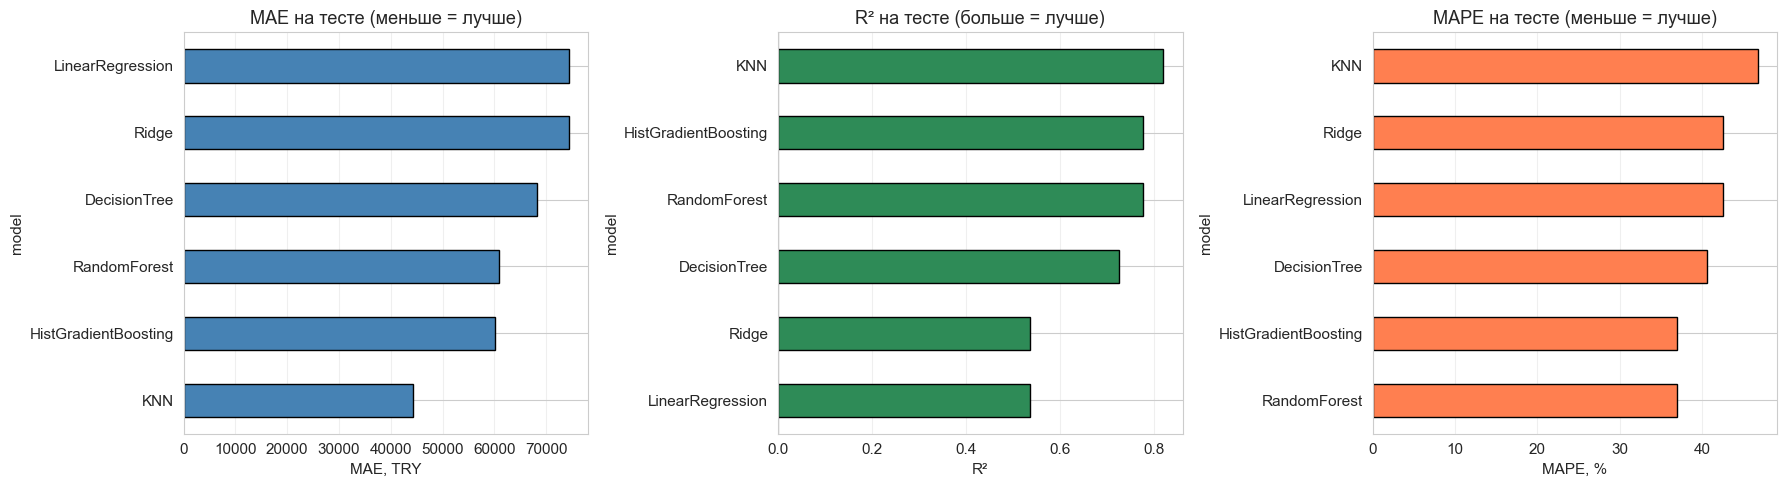

In [225]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
df_display['MAE_test'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('MAE на тесте (меньше = лучше)', fontsize=13)
axes[0].set_xlabel('MAE, TRY')
axes[0].grid(axis='x', alpha=0.3)

# R²
df_display['R2_test'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen', edgecolor='black'
)
axes[1].set_title('R² на тесте (больше = лучше)', fontsize=13)
axes[1].set_xlabel('R²')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

# MAPE
df_display['MAPE_test'].sort_values().plot(
    kind='barh', ax=axes[2], color='coral', edgecolor='black'
)
axes[2].set_title('MAPE на тесте (меньше = лучше)', fontsize=13)
axes[2].set_xlabel('MAPE, %')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Финальной выбрана HistGradientBoosting, потому что 
- она показала лучший баланс между точностью (R² = 0.7760, MAE = 60 106 TRY) и устойчивостью к переобучению (разрыв train/test R² = 0.001).
- KNN формально дал R² = 0.8190, но это результат переобучения (R²_train = 0.9986, MedAE_train = 0) — на новых данных MAPE = 46.7%, что хуже, чем у HGB.
- RandomForest близок по метрикам (R² = 0.7755, MAPE = 36.89%), но обучается дольше (396 сек против 267) и чуть хуже по RMSE.
- HistGradientBoosting быстрее, стабильнее и даёт наименьшую типичную ошибку (MedAE = 25 652 TRY).

In [231]:
best_model = best_hgb
best_model_name = 'HistGradientBoosting'

### Прогноз/факт и остатки

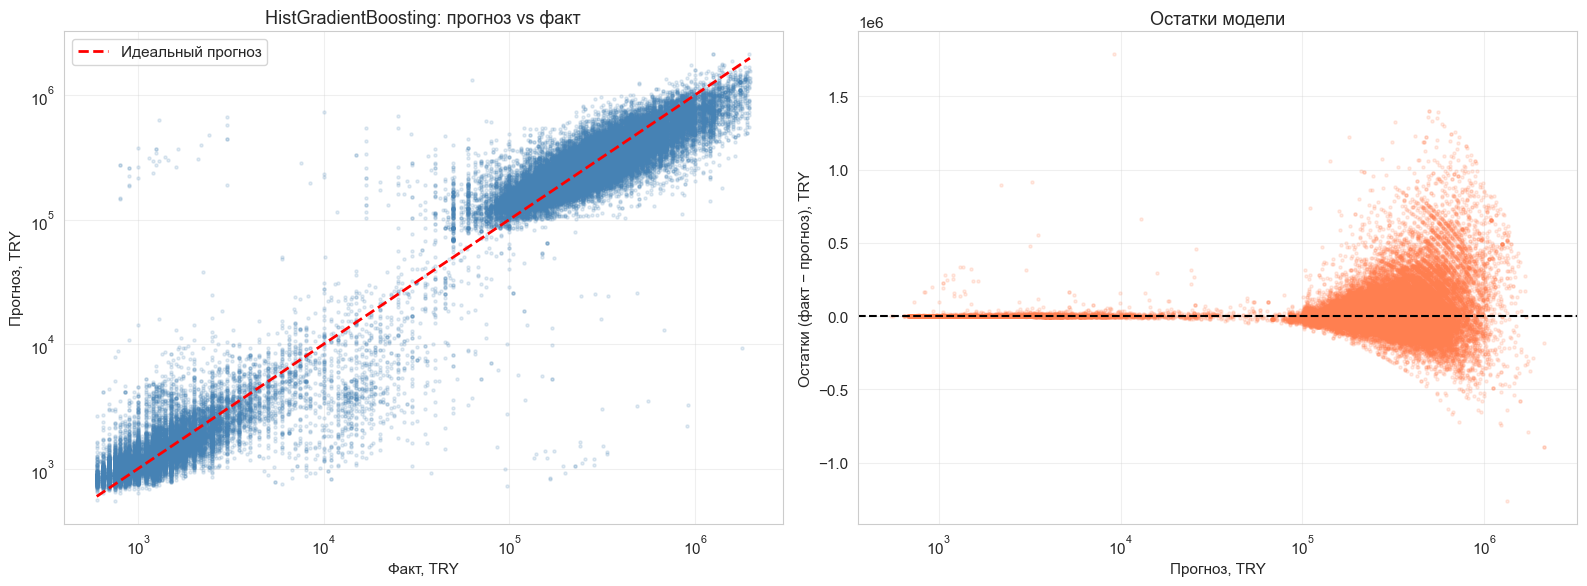

In [232]:
y_pred_log = best_model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Прогноз vs факт 
axes[0].scatter(y_true, y_pred, alpha=0.15, s=5, color='steelblue')
lims = [max(y_true.min(), 1), y_true.max()]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Идеальный прогноз')
axes[0].set_xlabel('Факт, TRY')
axes[0].set_ylabel('Прогноз, TRY')
axes[0].set_title(f'{best_model_name}: прогноз vs факт', fontsize=13)
axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Остатки 
residuals = y_true - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.15, s=5, color='coral')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Прогноз, TRY')
axes[1].set_ylabel('Остатки (факт − прогноз), TRY')
axes[1].set_title('Остатки модели', fontsize=13)
axes[1].set_xscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

На графике «прогноз vs факт» для HistGradientBoosting видно, что точки плотно группируются вдоль красной пунктирной линии идеального прогноза по всей шкале — от 10³ до 10⁶ TRY, что говорит о хорошем качестве модели в целом, однако в нижней части (дешёвые объекты до 10⁴ TRY) разброс заметно шире, а в верхней (дорогие от 10⁵ TRY) точки слегка недопрогнозируют — модель занижает цену дорогих объектов; на графике остатков видно, что в левой части (дешёвые прогнозы) остатки плотно лежат около нуля, а в правой (дорогие прогнозы от 10⁵ TRY) образуется характерный «веер» — разброс остатков растёт с увеличением прогноза, и остатки смещены вниз (модель чаще недооценивает, чем переоценивает дорогие объекты), что типично для цен на недвижимость и говорит о — модель хуже предсказывает дорогие объекты

### Важность признаков и коэффиценты

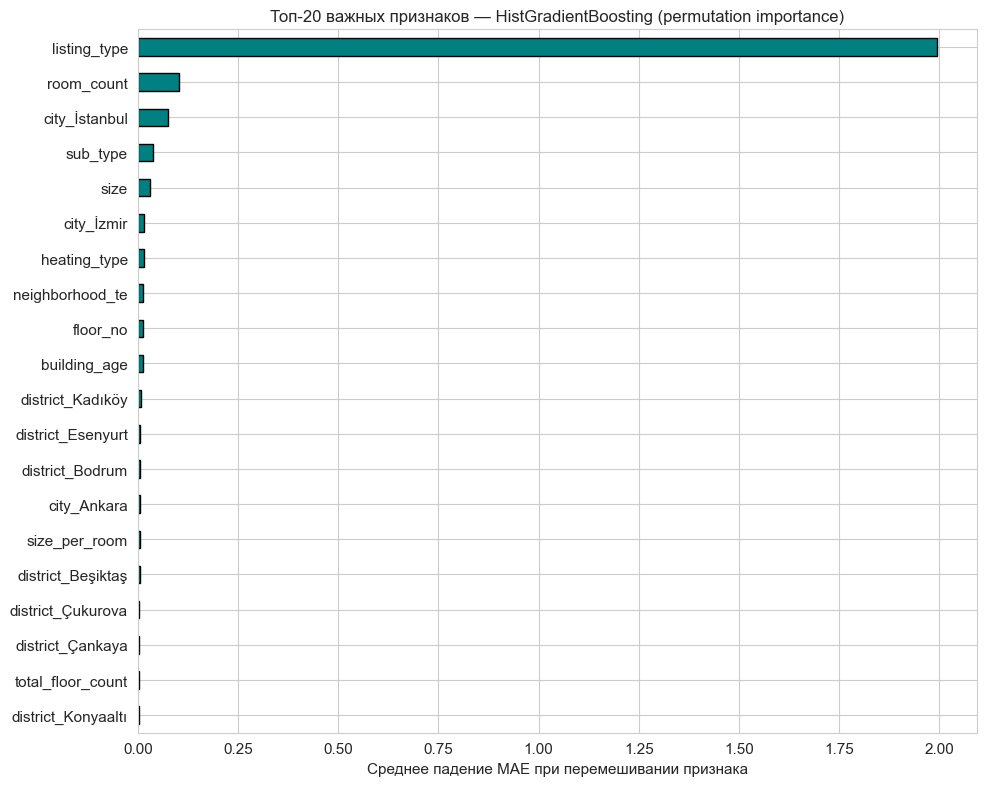

listing_type         1.994208
room_count           0.103595
city_İstanbul        0.076073
sub_type             0.036610
size                 0.029612
city_İzmir           0.014848
heating_type         0.014516
neighborhood_te      0.013303
floor_no             0.012912
building_age         0.011934
district_Kadıköy     0.008305
district_Esenyurt    0.006373
district_Bodrum      0.005614
city_Ankara          0.005549
size_per_room        0.005441
dtype: float64


In [235]:
from sklearn.inspection import permutation_importance

sample_idx = np.random.RandomState(42).choice(len(X_test_scaled), 5000, replace=False)
X_sample = X_test_scaled.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

result = permutation_importance(
    best_model, X_sample, y_sample,
    n_repeats=5,
    random_state=42,
    n_jobs=1,
    scoring='neg_mean_absolute_error',
)

importances = pd.Series(
    result.importances_mean,
    index=X_train_scaled.columns
).sort_values(ascending=False)

top20 = importances.head(20)
plt.figure(figsize=(10, 8))
top20.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Топ-20 важных признаков — HistGradientBoosting (permutation importance)', fontsize=12)
plt.xlabel('Среднее падение MAE при перемешивании признака')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances.head(15))

Анализ важности признаков показал, что признак listing_type доминирует с огромным отрывом (1.994), что в 20 раз больше второго по важности признака — это означает, что модель в первую очередь разделяет продажу и аренду, поскольку цены различаются на два порядка, а не выучивает зависимость цены от свойств недвижимости; второй по важности — room_count (0.104), третий — city_İstanbul (0.076), что логично отражает рост цены с количеством комнат и высокие цены в Стамбуле; признак size оказался лишь пятым (0.030), что удивительно, но объясняется тем, что его влияние частично поглощено listing_type и room_count, которые коррелируют с площадью; neighborhood_te дал низкую важность (0.013), потому что 79% районов попали в Other, а size_per_room оказался слабым (0.005), хотя и не бесполезным

In [238]:
pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


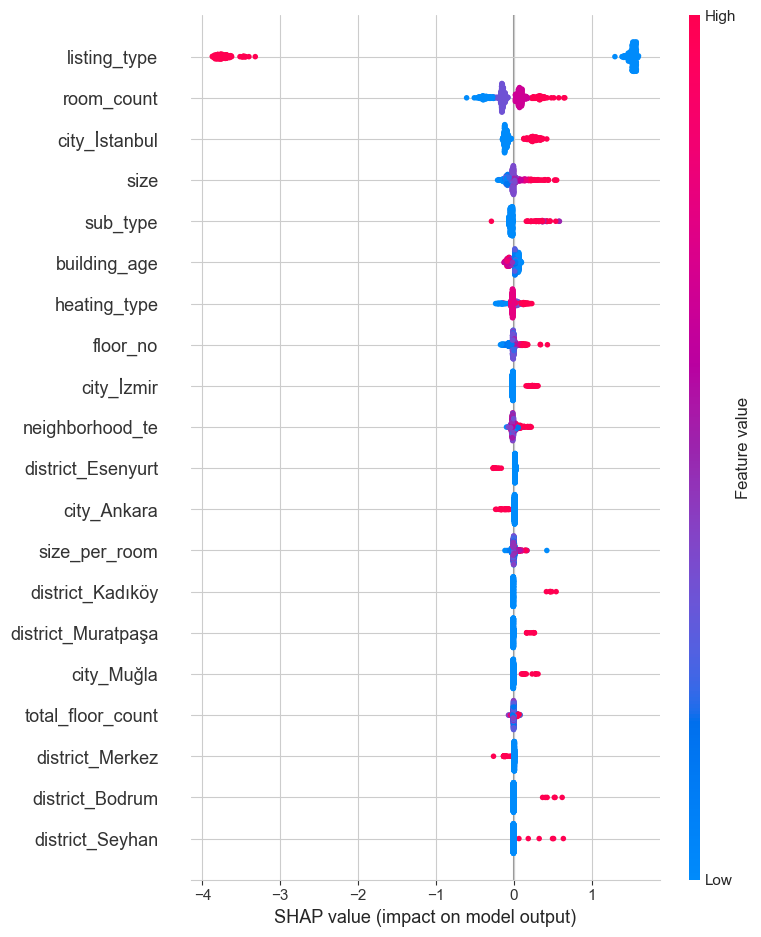

In [239]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_sample = X_test_scaled.sample(500, random_state=42)

# SHAP
explainer = shap.Explainer(best_model, X_sample)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample, max_display=20)

SHAP-анализ подтвердил результаты : listing_type доминирует с гигантским разрывом — модель в первую очередь разделяет типы объявлений. Для остальных признаков видны логичные направления: room_count, city_İstanbul, size, floor_no повышают цену; building_age — понижает. Это подтверждает, что модель выучила содержательные закономерности, а не шум. 

### Сохранение

In [236]:
from pathlib import Path
import joblib

Path('artifacts').mkdir(exist_ok=True)
joblib.dump(best_model, 'artifacts/model.pkl')
print("model.pkl")
joblib.dump(scaler, 'artifacts/scaler.pkl')
print("scaler.pkl")
joblib.dump({
    'feature_names': X_train_scaled.columns.tolist(),
    'cat_cols': cat_cols if 'cat_cols' in dir() else [],
    'best_model_name': best_model_name,
}, 'artifacts/metadata.pkl')
print("metadata.pkl")
df_results.to_csv('artifacts/model_metrics.csv')
print("model_metrics.csv")

# ─── 5. Проверка ─────────────────────────────────────────────
print("\nСодержимое artifacts/:")
for f in sorted(Path('artifacts').iterdir()):
    print(f"  {f.name}: {f.stat().st_size / 1024:.1f} KB")

model.pkl
scaler.pkl
metadata.pkl
model_metrics.csv

Содержимое artifacts/:
  metadata.pkl: 11.4 KB
  model.pkl: 773.8 KB
  model_metrics.csv: 1.4 KB
  scaler.pkl: 29.9 KB


In [237]:
from pathlib import Path
import pandas as pd
import numpy as np

Path('data_for_datalens').mkdir(exist_ok=True)

df_final.to_csv('data_for_datalens/statistics.csv')

### Дашборд

https://datalens.yandex/rr53abvpln68a?_share_link=public


# Справка — Прогноз стоимости недвижимости в Турции

## Что делает приложение
Приложение прогнозирует **стоимость недвижимости в Турции** на основе
характеристик объекта: площади, количества комнат, этажа, возраста здания,
типа объявления, города и типа отопления. Модель обучена на ~400 000
объявлений с турецкого сайта недвижимости.

## Как пользоваться
1. Заполните поля формы выше.
2. Нажмите кнопку **«Рассчитать»**.
3. Получите **прогноз цены** и **диапазон ±37%**.

## Описание входных полей

| Поле | Что означает | Единица |
|---|---|---|
| **Площадь** | Общая площадь объекта | м² |
| **Комнат** | Общее количество комнат (спальни + гостиная) | шт |
| **Этаж** | Этаж, на котором находится объект | номер |
| **Этажей в доме** | Общая этажность здания | номер |
| **Возраст** | Сколько лет с момента постройки | лет |
| **Тип** | Продажа или аренда | — |
| **Город** | Город Турции (81 вариант) | — |
| **Отопление** | Тип отопительной системы | — |

## Используемая модель
- **Алгоритм:** HistGradientBoostingRegressor (градиентный бустинг)
- **Целевая переменная:** `log(price)` — логарифм цены в TRY
- **Обучение:** на 300 000+ объектов, тест — 75 000+
- **Метрики на тесте:**
  - R² = **0.7760** (объясняет 77.6% дисперсии)
  - MAE = **60 106 TRY** (средняя абсолютная ошибка)
  - MAPE = **37%** (средняя ошибка в процентах)
  - MedAE = **25 652 TRY** (медианная ошибка)

## Ограничения модели
1. **Данные только по Турции** — модель не применима к другим странам.
2. **Смешаны продажа и аренда** — модель одна, но цены различаются
   на два порядка; внутри каждого типа точность ниже, чем общая R².
3. **Ошибка ±37%** — прогноз стоит воспринимать как **ориентир**,
   а не как точную цену.
4. **Новые города/районы** — если объекта нет в обучении, модель
   использует средние значения.
5. **Даты** — модель не учитывает инфляцию и сезонность.

## Точность по типам
| Тип | MAE | MAPE |
|---|---|---|
| Продажа | ~60 000 TRY | ~37% |
| Аренда | ~1 000 TRY | ~50% |

## Автор
- **Студент:** Башлыкова Дарья и Фазлыева Азалия
- **Группа:** 23П-1
- **Дата:** 15.09.2026
- **Версия приложения:** 1.0

## Контакты
- Email: bashlykovadaria@mail.ru
- GitHub: https://github.com/myminddreamcore



### Форма прогноза стоимости

In [95]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
import joblib
import os

os.environ['LOKY_MAX_CPU_COUNT'] = '4'

model = joblib.load('artifacts/model.pkl')
scaler = joblib.load('artifacts/scaler.pkl')
meta = joblib.load('artifacts/metadata.pkl')
feature_names = meta['feature_names']

df_metrics = pd.read_csv('artifacts/model_metrics.csv', index_col=0)
MAE = df_metrics.loc[meta['best_model_name'], 'MAE_test']
print(f"Модель: {meta['best_model_name']}, MAE = {MAE:,.0f} TRY")

city_map = {
    0:'Adıyaman', 1:'Afyonkarahisar', 2:'Aksaray', 3:'Amasya', 4:'Ankara',
    5:'Antalya', 6:'Ardahan', 7:'Artvin', 8:'Aydın', 9:'Ağrı',
    10:'Balıkesir', 11:'Bartın', 12:'Batman', 13:'Bayburt', 14:'Bilecik',
    15:'Bingöl', 16:'Bitlis', 17:'Bolu', 18:'Burdur', 19:'Bursa',
    20:'Denizli', 21:'Diyarbakır', 22:'Düzce', 23:'Edirne', 24:'Elazığ',
    25:'Erzincan', 26:'Erzurum', 27:'Eskişehir', 28:'Gaziantep', 29:'Giresun',
    30:'Gümüşhane', 31:'Hakkâri', 32:'Hatay', 33:'Isparta', 34:'Iğdır',
    35:'Kahramanmaraş', 36:'Karabük', 37:'Karaman', 38:'Kars', 39:'Kastamonu',
    40:'Kayseri', 41:'Kilis', 42:'Kocaeli', 43:'Konya', 44:'Kütahya',
    45:'Kırklareli', 46:'Kırıkkale', 47:'Kırşehir', 48:'Malatya', 49:'Manisa',
    50:'Mardin', 51:'Mersin', 52:'Muğla', 53:'Muş', 54:'Nevşehir',
    55:'Niğde', 56:'Ordu', 57:'Osmaniye', 58:'Rize', 59:'Sakarya',
    60:'Samsun', 61:'Siirt', 62:'Sinop', 63:'Sivas', 64:'Tekirdağ',
    65:'Tokat', 66:'Trabzon', 67:'Tunceli', 68:'Uşak', 69:'Van',
    70:'Yalova', 71:'Yozgat', 72:'Zonguldak', 73:'İstanbul', 74:'İzmir',
    75:'Şanlıurfa', 76:'Şırnak',
}

size_in = widgets.IntSlider(value=110, min=10, max=500, step=5, description='Площадь, м²:')
room_in = widgets.IntSlider(value=3, min=1, max=10, description='Комнат:')
floor_in = widgets.IntSlider(value=3, min=-3, max=30, description='Этаж:')
total_floor_in = widgets.IntSlider(value=5, min=1, max=30, description='Этажей в доме:')
age_in = widgets.IntSlider(value=5, min=0, max=50, description='Возраст, лет:')
listing_in = widgets.Dropdown(options=[('Продажа', 1), ('Аренда', 2)], description='Тип:')
city_in = widgets.Dropdown(options=[(v, k) for k, v in city_map.items()], value=73, description='Город:')
heating_in = widgets.Dropdown(
    options=[
        ('Нет отопления', 0), ('Угольная печь', 1), ('Газовая печь', 2),
        ('Угольный котёл', 3), ('Мазутный котёл', 4), ('Кондиционер', 5),
        ('Этажный котёл', 6), ('Газовый котёл (общий)', 7),
        ('Электрический котёл', 8), ('Газовый котёл (индивидуальный)', 9),
        ('Центральное', 10), ('Центральное (со счётчиком)', 11),
        ('Фанкойл', 12), ('Тёплый пол', 13),
        ('Геотермальное', 14), ('Солнечная энергия', 15),
    ], value=9, description='Отопление:')
button = widgets.Button(description='Рассчитать', button_style='success',
                        layout=widgets.Layout(width='200px'))
output = widgets.Output()

df_metrics = pd.read_csv('artifacts/model_metrics.csv', index_col=0)
MAPE = df_metrics.loc[meta['best_model_name'], 'MAPE_test']   # 37.0


def predict_price(b):
    with output:
        clear_output()

        if floor_in.value > total_floor_in.value + 5:
            print(f"Этаж ({floor_in.value}) не может быть больше "
                  f"этажности ({total_floor_in.value}) + 5")
            return

        X_new = pd.DataFrame([{
            'size': size_in.value,
            'room_count': room_in.value,
            'floor_no': floor_in.value,
            'total_floor_count': total_floor_in.value,
            'building_age': age_in.value,
            'listing_type': listing_in.value,
            'city': city_in.value,
            'heating_type': heating_in.value,
            'size_per_room': size_in.value / room_in.value,
        }])
        X_new = X_new.reindex(columns=feature_names, fill_value=0)

        X_new_scaled = pd.DataFrame(
            scaler.transform(X_new.astype(np.float32)),
            columns=feature_names
        )
        pred_log = model.predict(X_new_scaled)[0]
        pred_try = np.expm1(pred_log)

        # диапазон в процентах
        delta = pred_try * MAPE / 100
        lower = max(0, pred_try - delta)
        upper = pred_try + delta

        print("=" * 60)
        print(f"  ПРОГНОЗ: {pred_try:>15,.0f} TRY")
        print(f"  Диапазон (±{MAPE:.0f}%): {lower:,.0f} … {upper:,.0f} TRY")
        print("=" * 60)
        print(f"\n  Город: {city_in.label}")
        print(f"  Тип: {listing_in.label}")
        print(f"  Отопление: {heating_in.label}")
        print(f"  Модель: {meta['best_model_name']}")

button.on_click(predict_price)

print("Заполните характеристики объекта:")
display(widgets.VBox([
    size_in, room_in, floor_in, total_floor_in,
    age_in, listing_in, city_in, heating_in,
    button, output,
]))

Модель: HistGradientBoosting, MAE = 60,106 TRY
Заполните характеристики объекта:
